In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\praty\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [4]:
data = pd.read_csv('fake_job_postings.csv')

In [5]:
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [6]:
print('Dataset Shape:', data.shape)

Dataset Shape: (17880, 18)


In [7]:
print(data.columns.tolist())

['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [9]:
missing = data.isnull().sum().sort_values(ascending=False)
missing

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
title                      0
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
fraudulent                 0
dtype: int64

In [10]:
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_percent.sort_values(ascending=False)

salary_range           83.959732
department             64.580537
required_education     45.329978
benefits               40.335570
required_experience    39.429530
function               36.101790
industry               27.421700
employment_type        19.412752
company_profile        18.501119
requirements           15.078300
location                1.935123
description             0.005593
title                   0.000000
job_id                  0.000000
telecommuting           0.000000
has_questions           0.000000
has_company_logo        0.000000
fraudulent              0.000000
dtype: float64

In [11]:
missing_df = pd.DataFrame({
    'Missing Count': data.isnull().sum(),
    'Missing Percent': (data.isnull().sum() / len(data)) * 100
})

missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df.sort_values('Missing Count', ascending=False)

,Missing Count,Missing Percent
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


C:\Users\praty\AppData\Local\Temp\ipykernel_19276\2433464753.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='fraudulent', palette='Set2')


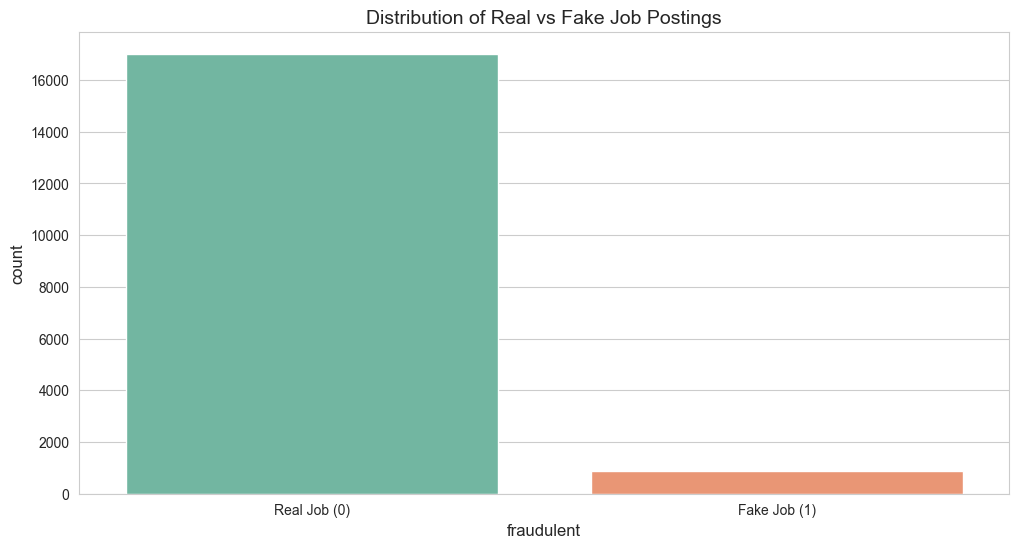

In [12]:
sns.countplot(data=data, x='fraudulent', palette='Set2')
plt.title('Distribution of Real vs Fake Job Postings')
plt.xticks([0, 1], ['Real Job (0)', 'Fake Job (1)'])
plt.show()

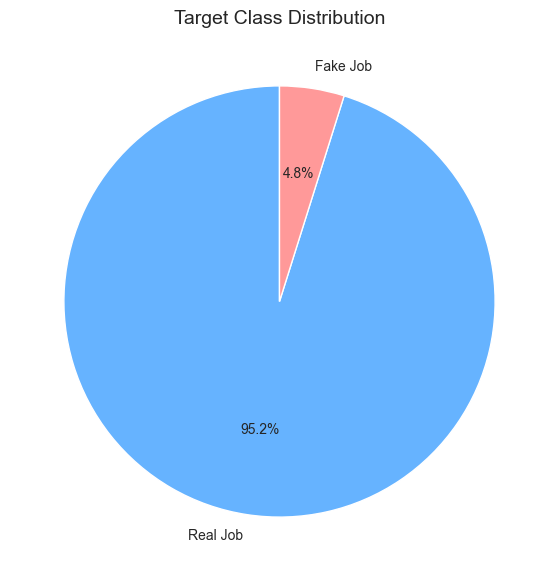

In [13]:
counts = data['fraudulent'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    counts.values,
    labels=['Real Job', 'Fake Job'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999']
)
plt.title('Target Class Distribution')
plt.show()

C:\Users\praty\AppData\Local\Temp\ipykernel_19276\772001339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='coolwarm')


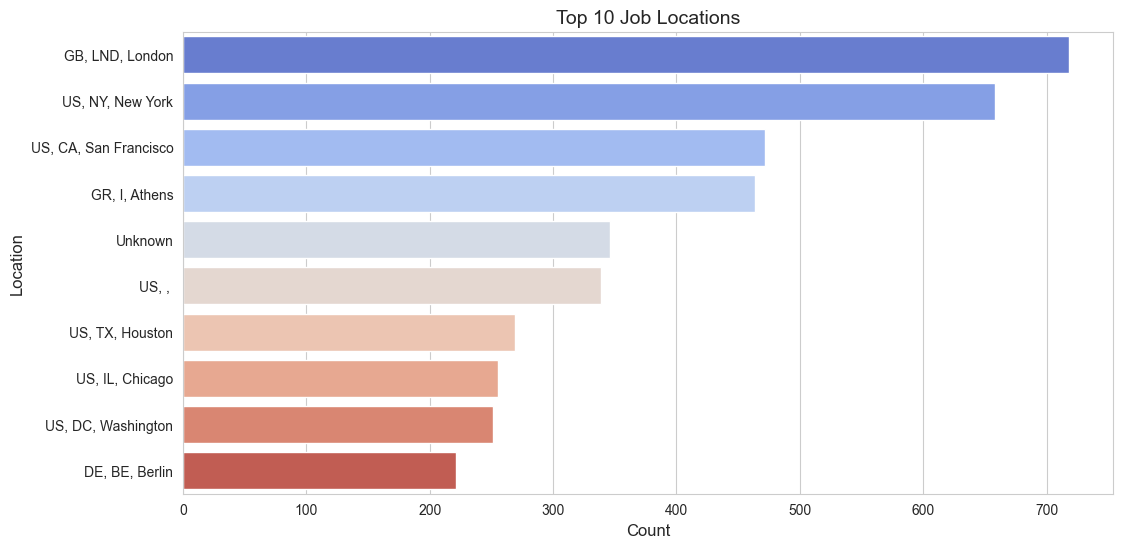

In [14]:
top_locations = data['location'].fillna('Unknown').value_counts().head(10)

sns.barplot(x=top_locations.values, y=top_locations.index, palette='coolwarm')
plt.title('Top 10 Job Locations')
plt.xlabel('Count')
plt.ylabel('Location')
plt.show()

C:\Users\praty\AppData\Local\Temp\ipykernel_19276\1520284396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_employment.values, y=top_employment.index, palette='Blues_r')


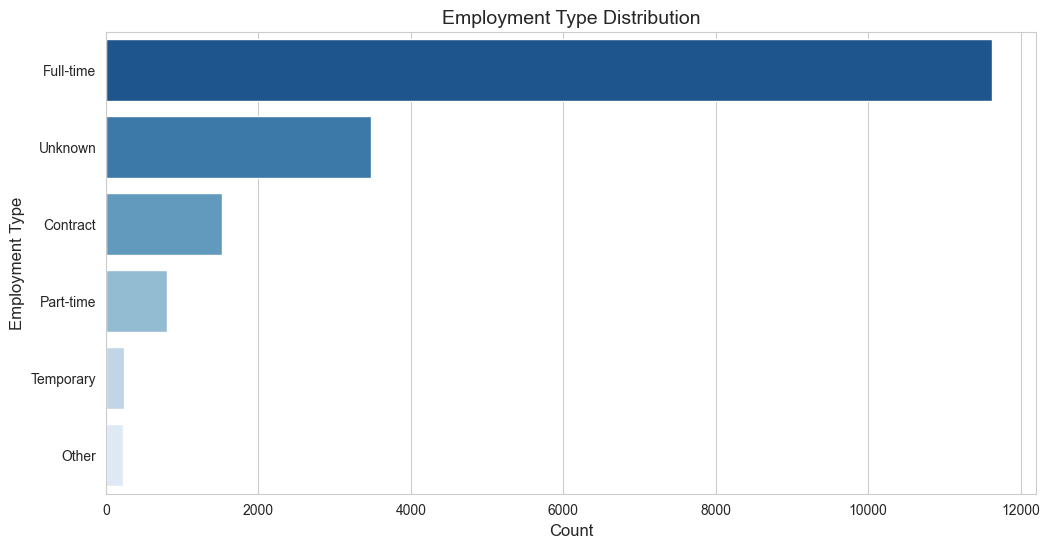

In [15]:
top_employment = data['employment_type'].fillna('Unknown').value_counts().head(10)

sns.barplot(x=top_employment.values, y=top_employment.index, palette='Blues_r')
plt.title('Employment Type Distribution')
plt.xlabel('Count')
plt.ylabel('Employment Type')
plt.show()

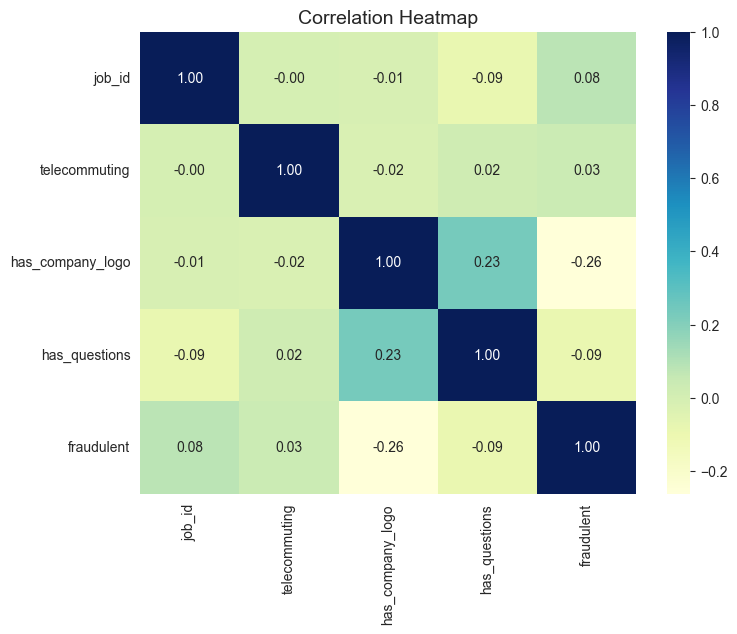

In [16]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [17]:
data['description_length'] = (
    data['description']
    .fillna('')
    .astype(str)
    .apply(len)
)

C:\Users\praty\AppData\Local\Temp\ipykernel_19276\2845612670.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


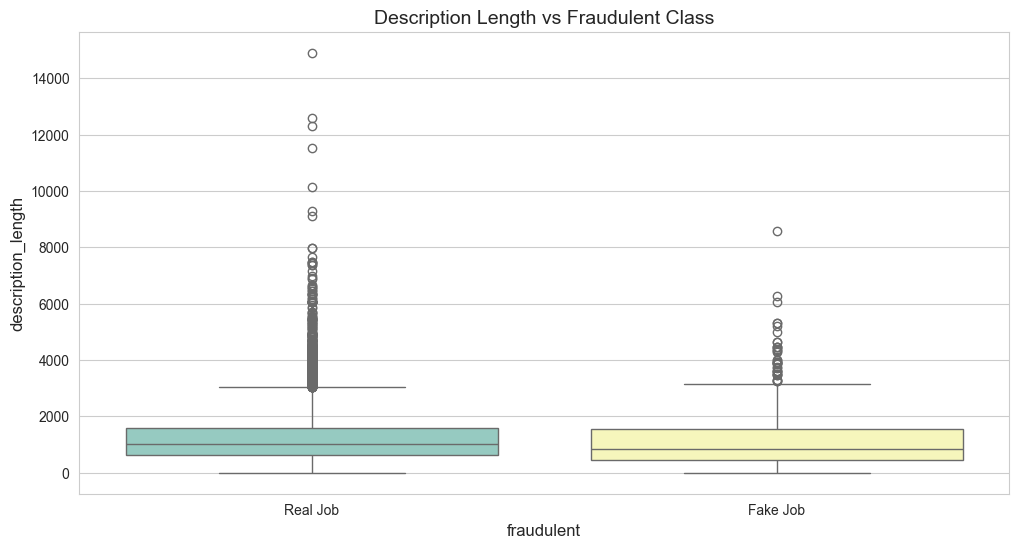

In [18]:
sns.boxplot(
    data=data,
    x='fraudulent',
    y='description_length',
    palette='Set3'
)
plt.xticks([0, 1], ['Real Job', 'Fake Job'])
plt.title('Description Length vs Fraudulent Class')
plt.show()

In [19]:
useful_columns = [
    'title',
    'location',
    'department',
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'telecommuting',
    'has_company_logo',
    'has_questions'
]

In [20]:
data = data[useful_columns + ['fraudulent']]

In [21]:
data = data[useful_columns + ['fraudulent']].copy()

In [24]:
for col in useful_columns:
    data[col] = data[col].astype(str)

# Combine all columns into one text column
data['text'] = data[useful_columns].agg(' '.join, axis=1)

In [25]:
data[['text', 'fraudulent']].head()

,text,fraudulent
0,"Marketing Intern US, NY, New York Marketing We...",0
1,"Customer Service - Cloud Video Production NZ, ...",0
2,"Commissioning Machinery Assistant (CMA) US, IA...",0
3,"Account Executive - Washington DC US, DC, Wash...",0
4,"Bill Review Manager US, FL, Fort Worth nan Spo...",0


In [26]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    return ' '.join(words)

In [27]:
data['text'] = data['text'].apply(preprocess_text)

In [28]:
data[['text', 'fraudulent']].head()

,text,fraudulent
0,marketing intern us ny new york marketing food...,0
1,customer service cloud video production nz auc...,0
2,commissioning machinery assistant cma us ia we...,0
3,account executive washington dc us dc washingt...,0
4,bill review manager us fl fort worth nan spots...,0


In [29]:
print('Final Dataset Shape:', data.shape)

Final Dataset Shape: (17880, 17)


In [30]:
data.head()

,title,location,department,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function,telecommuting,has_company_logo,has_questions,fraudulent,text
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,nan,Other,Internship,nan,nan,Marketing,0,1,0,0,marketing intern us ny new york marketing food...
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,Full-time,Not Applicable,nan,Marketing and Advertising,Customer Service,0,1,0,0,customer service cloud video production nz auc...
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",nan,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,nan,nan,nan,nan,nan,nan,0,1,0,0,commissioning machinery assistant cma us ia we...
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,1,0,0,account executive washington dc us dc washingt...
4,Bill Review Manager,"US, FL, Fort Worth",nan,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,1,1,0,bill review manager us fl fort worth nan spots...


In [43]:
# Separate the two classes
real_jobs = data[data['fraudulent'] == 0]
fake_jobs = data[data['fraudulent'] == 1]

# Count fake jobs
n_fake = len(fake_jobs)

# We want real jobs = 2 × fake jobs
n_real_required = 2 * n_fake

# Randomly sample real jobs
real_jobs_sampled = real_jobs.sample(
    n=n_real_required,
    random_state=42
)

# Combine sampled real jobs with all fake jobs
data = pd.concat(
    [real_jobs_sampled, fake_jobs],
    axis=0
)

# Shuffle the dataset
data = data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Check new class distribution
print(data['fraudulent'].value_counts())

fraudulent
0    1732
1     866
Name: count, dtype: int64


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    data.text,
    data.fraudulent,
    test_size=0.30,
    random_state=42,
    stratify=data.fraudulent
)

In [45]:
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (1818,)
X_test shape : (780,)
y_train shape: (1818,)
y_test shape : (780,)


In [46]:
X_train.head()

633     junior web developer data analyst gr b nan bar...
452     c developer lt vl vilnius research nan adform ...
990     sap support advisor us tx houston aker solutio...
1285    qc inspector us tx houston nan nan corporate o...
1942    front end developer cy nicosia nan url bda e d...
Name: text, dtype: object

In [47]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [48]:
print('X_train_tfidf shape:', X_train_tfidf.shape)
print('X_test_tfidf shape :', X_test_tfidf.shape)

X_train_tfidf shape: (1818, 5000)
X_test_tfidf shape : (780, 5000)


In [49]:
X_train_idf = X_train_tfidf
X_test_idf = X_test_tfidf

In [50]:
print('Vocabulary Size:', len(tfidf.vocabulary_))

Vocabulary Size: 5000


# Model Building & evaluation

In [51]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

<h2>Naive Bayes</h2>

In [52]:
# Create model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_tfidf)

In [53]:
# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Accuracy : 0.9166666666666666
Precision: 0.925764192139738
Recall   : 0.8153846153846154
F1 Score : 0.8670756646216768


In [54]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[503  17]
 [ 48 212]]


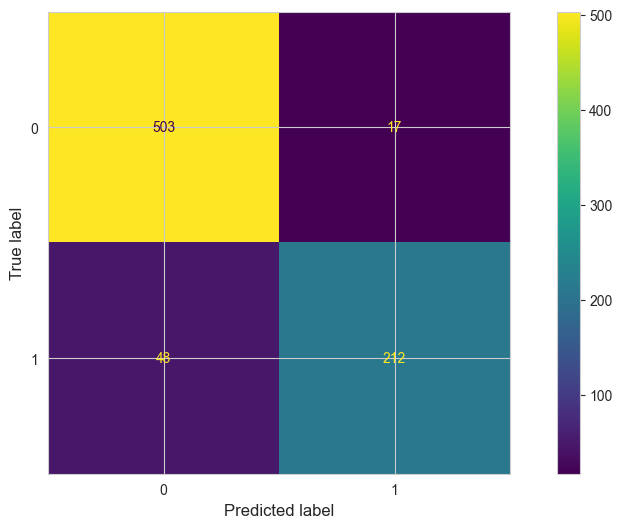

In [55]:
# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

Classification Accuracy: 0.9166666666666666
Classification Report

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       520
           1       0.93      0.82      0.87       260

    accuracy                           0.92       780
   macro avg       0.92      0.89      0.90       780
weighted avg       0.92      0.92      0.92       780

Confusion Matrix

[[503  17]
 [ 48 212]]


Text(95.72222222222221, 0.5, 'Truth')

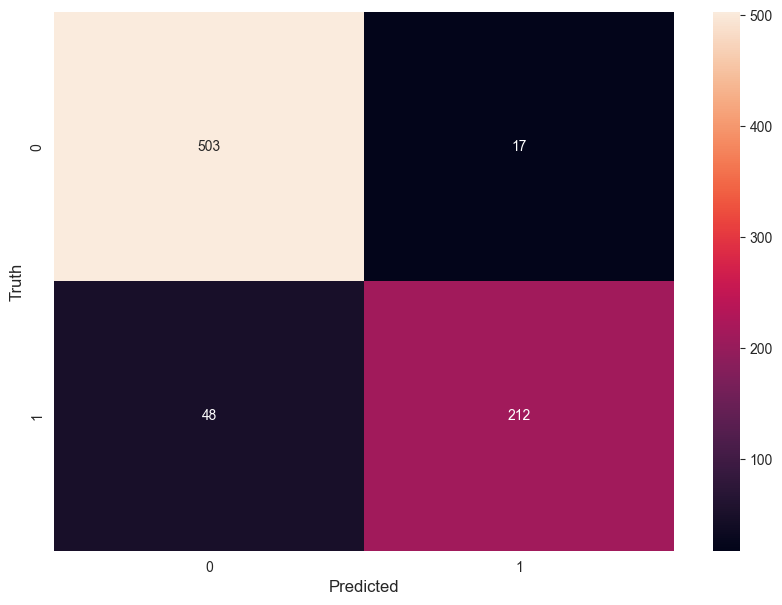

In [56]:
accuracy_score(y_test, y_pred_nb)
print("Classification Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report\n")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred_nb))


cm = confusion_matrix(y_test,y_pred_nb)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

## Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)


lr_model.fit(X_train_tfidf, y_train)


y_pred_lr = lr_model.predict(X_test_tfidf)

In [58]:
# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.9217948717948717
Precision: 0.9307359307359307
Recall   : 0.8269230769230769
F1 Score : 0.8757637474541752


In [59]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[504  16]
 [ 45 215]]


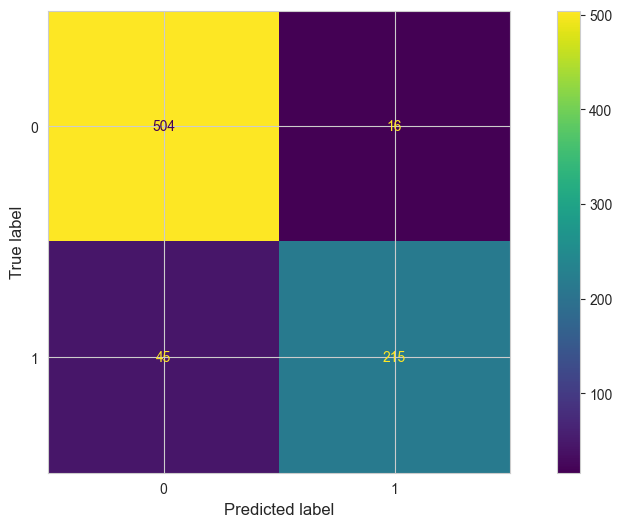

In [60]:
# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

## Suppport Vector Machine

In [61]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

In [62]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.9448717948717948
Precision: 0.9125475285171103
Recall   : 0.9230769230769231
F1 Score : 0.9177820267686424


In [63]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[497  23]
 [ 20 240]]


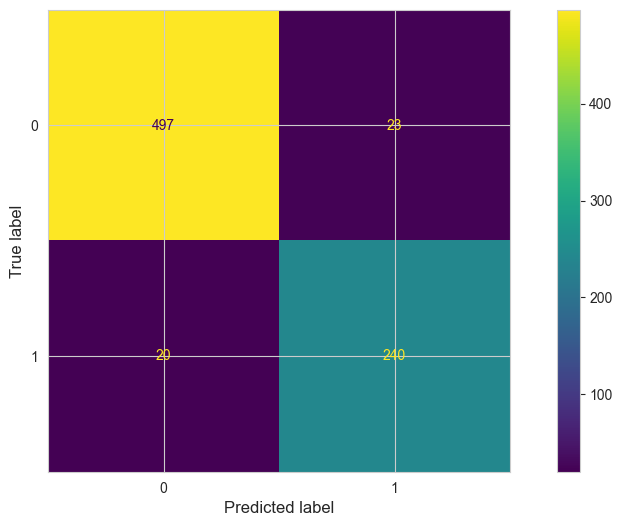

In [64]:
# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

## Decesion Tree Classifire

In [65]:
from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_tfidf, y_train)

y_pred_dt = dt_model.predict(X_test_tfidf)

In [66]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.8692307692307693
Precision: 0.7904411764705882
Recall   : 0.8269230769230769
F1 Score : 0.8082706766917294


In [67]:
cm = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[463  57]
 [ 45 215]]


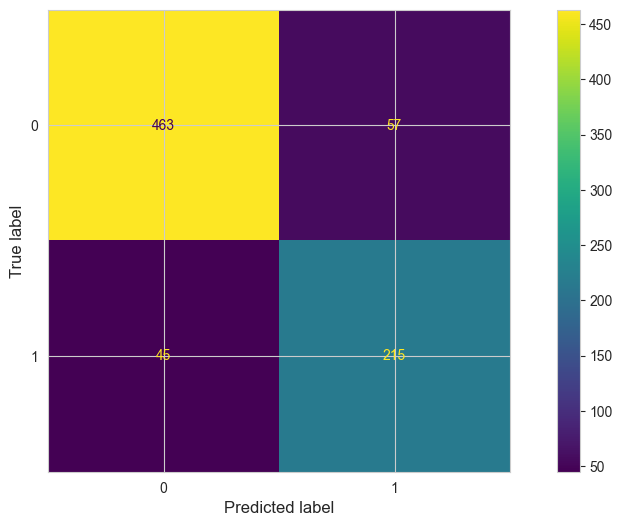

In [68]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

## Random Forest Claasifier

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

In [70]:
# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9346153846153846
Precision: 0.9300411522633745
Recall   : 0.8692307692307693
F1 Score : 0.8986083499005965


In [71]:
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[503  17]
 [ 34 226]]


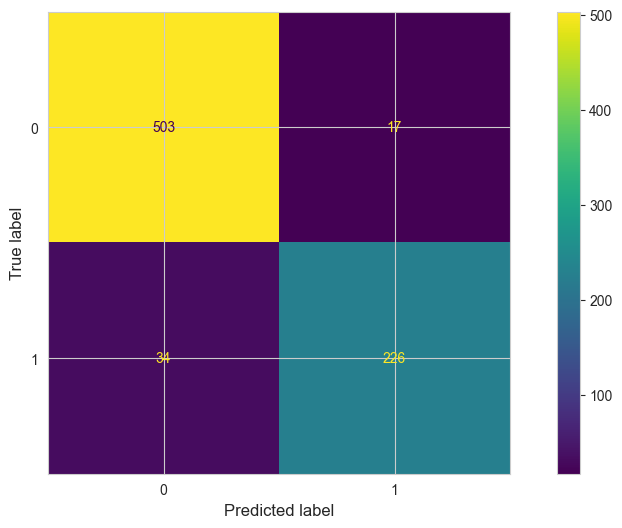

In [72]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [73]:
from sklearn.ensemble import AdaBoostClassifier

adb_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adb_model.fit(X_train_tfidf, y_train)

y_pred_adb = adb_model.predict(X_test_tfidf)

In [74]:
print("Accuracy :", accuracy_score(y_test, y_pred_adb))
print("Precision:", precision_score(y_test, y_pred_adb))
print("Recall   :", recall_score(y_test, y_pred_adb))
print("F1 Score :", f1_score(y_test, y_pred_adb))

Accuracy : 0.8833333333333333
Precision: 0.8477366255144033
Recall   : 0.7923076923076923
F1 Score : 0.8190854870775348


In [75]:
cm = confusion_matrix(y_test, y_pred_adb)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[483  37]
 [ 54 206]]


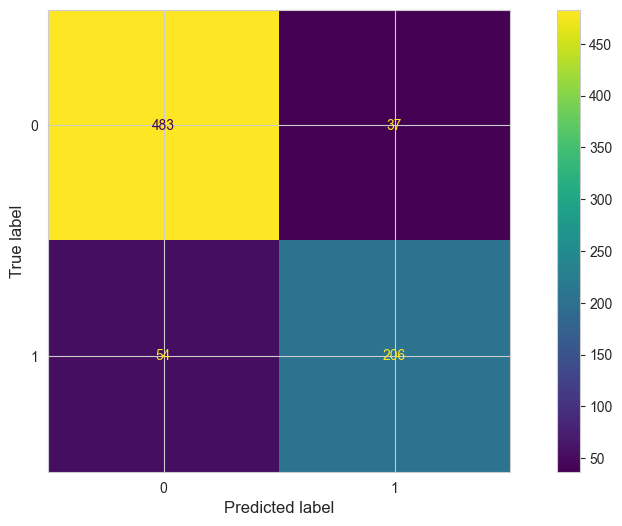

In [76]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

## KNN

In [77]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_tfidf, y_train)

y_pred_knn = knn_model.predict(X_test_tfidf)

In [78]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

Accuracy : 0.9
Precision: 0.7993421052631579
Recall   : 0.9346153846153846
F1 Score : 0.8617021276595744


In [79]:
cm = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[459  61]
 [ 17 243]]


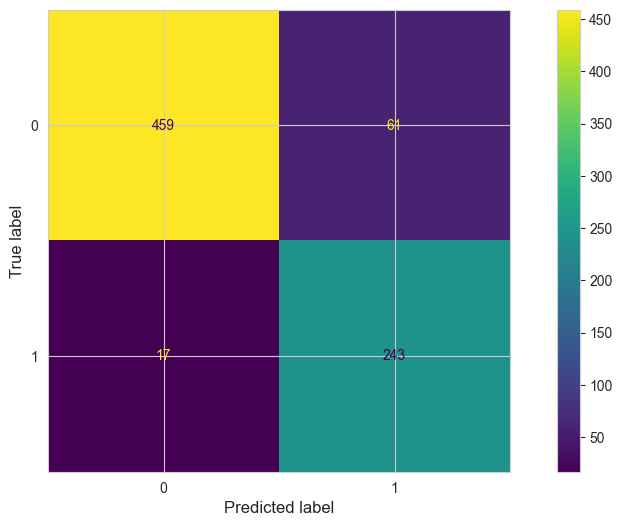

In [80]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

## Making the real modek and pPipeline using SVM

In [81]:
sample_job = {
    "title": "Python Developer",
    "location": "New York, USA",
    "department": "Engineering",
    "company_profile": "Fast growing software company",
    "description": "Looking for a Django developer with 2 years experience",
    "requirements": "Python, Django, REST API",
    "benefits": "Health insurance, remote work",
    "employment_type": "Full-time",
    "required_experience": "Mid-Senior level",
    "required_education": "Bachelor's Degree",
    "industry": "Information Technology",
    "function": "Engineering",
    "telecommuting": 1,
    "has_company_logo": 1,
    "has_questions": 1
}

In [82]:
import pandas as pd
import re
import nltk
import joblib

from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Stopwords set
stop_words = set(stopwords.words('english'))

# Columns used in the project
useful_columns = [
    'title',
    'location',
    'department',
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'telecommuting',
    'has_company_logo',
    'has_questions'
]

# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\\s+', ' ', text).strip()

    # Remove stopwords
    words = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    return ' '.join(words)

# Batch preprocessing function
def prepare_features(X):
    # Convert input to DataFrame
    if isinstance(X, dict):
        X = pd.DataFrame([X])
    elif isinstance(X, list):
        X = pd.DataFrame(X)

    # Keep only useful columns
    X = X[useful_columns].copy()

    # Fill missing values
    X = X.fillna('')

    # Convert all columns to string
    for col in useful_columns:
        X[col] = X[col].astype(str)

    # Combine all columns into one text field
    X['text'] = X[useful_columns].agg(' '.join, axis=1)

    # Apply preprocessing
    X['text'] = X['text'].apply(preprocess_text)

    # Return cleaned text
    return X['text']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\praty\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [84]:
final_pipeline = Pipeline([
    (
        'feature_preparation',
        FunctionTransformer(
            prepare_features,
            validate=False
        )
    ),
    (
        'tfidf',
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2)
        )
    ),
    (
        'model',
        LinearSVC()
    )
])

In [85]:
# Train on original DataFrame (not just data['text'])
final_pipeline.fit(
    data[useful_columns],
    data['fraudulent']
)

,steps,"[('feature_preparation', ...), ('tfidf', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function pre...0019C568F3400>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [86]:
joblib.dump(final_pipeline, 'fake_job_detector.pkl')
print("Pipeline saved successfully.")

Pipeline saved successfully.
